# This notebook shows, how to read a csv file

In [88]:
path = '/home/bfh/rtdp/data/'


In [89]:
# using time module
import time
import requests as rq
import influxdb_client

oneHour = 60 * 60

# ts stores the time in seconds
ts = time.time() - oneHour
ip='http://localhost:5000'

# print the current timestamp
print(ts)

1774108955.8560076


In [90]:
from datetime import datetime, timezone
with open(path+"Light.csv", 'r') as data:
    csv_reader = list(reader(data))
    rows = csv_reader[1:]

    first_time = float(rows[0][0])
    last_time = float(rows[-1][0])
    first_dt = datetime.fromtimestamp(first_time, tz=timezone.utc)
    last_dt = datetime.fromtimestamp(last_time, tz=timezone.utc)
    print(f"First time in CSV: {first_time} ({first_dt.isoformat()})")
    print(f"Last time in CSV: {last_time} ({last_dt.isoformat()})")
    
    first_time = float(rows[0][0]) / 1_000_000_000
    last_time = float(rows[-1][0]) / 1_000_000_000
    first_dt = datetime.fromtimestamp(first_time, tz=timezone.utc)
    last_dt = datetime.fromtimestamp(last_time, tz=timezone.utc)
    print(f"First time in CSV: {first_time} ({first_dt.isoformat()})")
    print(f"Last time in CSV: {last_time} ({last_dt.isoformat()})")
    
    


First time in CSV: 129655130.0 (1974-02-09T15:18:50+00:00)
Last time in CSV: 14951527570.0 (2443-10-18T02:06:10+00:00)
First time in CSV: 0.12965513 (1970-01-01T00:00:00.129655+00:00)
Last time in CSV: 14.95152757 (1970-01-01T00:00:14.951528+00:00)


In [92]:
end_time = 0
start_time = 999999999999999999999

from csv import reader
with open (path+"Light.csv", 'r') as data:
    csv_reader = reader(data)
    max = float((list(csv_reader)[1:])[-1][0]) / 1_000_000_000  # 14s offeset
    print(max)
    data.seek(0)  # Reset the file pointer to the beginning
    header_to_skip = next(csv_reader)
    if header_to_skip != None:           # File is not empty
        for row in csv_reader:
            # do some computations with the timestamp
            # time = str(int(int(row[0]) / 1000_000_000 + int(ts / 1000)))
            
            if row[0] == '0':
                continue
            
            time = str((float(row[0]) / 1_000_000_000) + (ts -max)) # row[0] sind sekunden und ts auch 
            if float(time) < start_time:
                start_time = float(time)
            if float(time) > end_time:
                end_time = float(time)
            
            
            lx = row[1]
            
            data = {
                'time_sec': time,
                'lx': lx
            }
            
            response = rq.post(ip+"/generator", json=data)
            
            print(response.text)

14.95152757
{"lx":"854000000000","time_sec":"1774108941.034135"}

{"lx":"292000000000","time_sec":"1774108941.0943859"}

{"lx":"854000000000","time_sec":"1774108941.214841"}

{"lx":"869000000000","time_sec":"1774108941.9549935"}

{"lx":"879000000000","time_sec":"1774108942.555097"}

{"lx":"998000000000","time_sec":"1774108943.1071622"}

{"lx":"1233000000000","time_sec":"1774108943.5972092"}

{"lx":"1417000000000","time_sec":"1774108944.0686655"}

{"lx":"2247000000000","time_sec":"1774108944.5036843"}

{"lx":"3375000000000","time_sec":"1774108941.2884862"}

{"lx":"2387000000000","time_sec":"1774108941.6703022"}

{"lx":"1590000000000","time_sec":"1774108942.0352938"}

{"lx":"1231000000000","time_sec":"1774108942.3860543"}

{"lx":"871000000000","time_sec":"1774108942.7246146"}

{"lx":"1064000000000","time_sec":"1774108943.064599"}

{"lx":"1733000000000","time_sec":"1774108943.3946435"}

{"lx":"2306000000000","time_sec":"1774108943.715918"}

{"lx":"3376000000000","time_sec":"1774108944.029

In [93]:
from datetime import datetime, timezone

def to_rfc3339(secs):
    return datetime.fromtimestamp(secs, tz=timezone.utc).isoformat()

start_rfc3339 = to_rfc3339(start_time)
end_rfc3339 = to_rfc3339(end_time)

print("Start time:", start_rfc3339)
print("End time:", end_rfc3339)

Start time: 2026-03-21T16:02:21.034135+00:00
End time: 2026-03-21T16:02:35.856008+00:00


In [94]:
query = f'''from(bucket: "bfh")
|> range(start: {start_rfc3339}, stop: {end_rfc3339})
|> filter(fn: (r) => r._measurement == "light")
|> filter(fn: (r) => r._field == "lx")'''

print(query)

from(bucket: "bfh")
|> range(start: 2026-03-21T16:02:21.034135+00:00, stop: 2026-03-21T16:02:35.856008+00:00)
|> filter(fn: (r) => r._measurement == "light")
|> filter(fn: (r) => r._field == "lx")


In [95]:
path = '/home/bfh/rtdp/bfh-rtdp/roller/'
bucket = "bfh"
org = "bfh"
token = "7GI7A2cyVrR7_GsmFI-CQzPFWHbguzIJmHj_XvfrmttOVnEqCKn6NefOYnBdybQVqEmZAu8gfdYbyqjgblmB6w=="
url="http://localhost:8086"

client = influxdb_client.InfluxDBClient(
   url=url,
   token=token,
   org=org
)

query_api = client.query_api()
result = query_api.query(org=org, query=query)

In [96]:
results = []
for table in result:
  for record in table.records:
    results.append((record.get_time(), record.get_value()))

print(results)

[(datetime.datetime(2026, 3, 21, 16, 2, 21, 34135, tzinfo=tzutc()), 854000000000.0), (datetime.datetime(2026, 3, 21, 16, 2, 21, 94385, tzinfo=tzutc()), 292000000000.0), (datetime.datetime(2026, 3, 21, 16, 2, 21, 214840, tzinfo=tzutc()), 854000000000.0), (datetime.datetime(2026, 3, 21, 16, 2, 21, 288486, tzinfo=tzutc()), 3375000000000.0), (datetime.datetime(2026, 3, 21, 16, 2, 21, 670302, tzinfo=tzutc()), 2387000000000.0), (datetime.datetime(2026, 3, 21, 16, 2, 21, 954993, tzinfo=tzutc()), 869000000000.0), (datetime.datetime(2026, 3, 21, 16, 2, 22, 35293, tzinfo=tzutc()), 1590000000000.0), (datetime.datetime(2026, 3, 21, 16, 2, 22, 386054, tzinfo=tzutc()), 1231000000000.0), (datetime.datetime(2026, 3, 21, 16, 2, 22, 555097, tzinfo=tzutc()), 879000000000.0), (datetime.datetime(2026, 3, 21, 16, 2, 22, 724614, tzinfo=tzutc()), 871000000000.0), (datetime.datetime(2026, 3, 21, 16, 2, 23, 64599, tzinfo=tzutc()), 1064000000000.0), (datetime.datetime(2026, 3, 21, 16, 2, 23, 107162, tzinfo=tzutc

In [97]:
import pandas as pd
res_df = pd.DataFrame(results, columns=['time', 'value', ])
res_df.set_index('time')

,value
time,
2026-03-21 16:02:21.034135+00:00,8.540000e+11
2026-03-21 16:02:21.094385+00:00,2.920000e+11
2026-03-21 16:02:21.214840+00:00,8.540000e+11
2026-03-21 16:02:21.288486+00:00,3.375000e+12
2026-03-21 16:02:21.670302+00:00,2.387000e+12
...,...
2026-03-21 16:02:34.884244+00:00,1.597000e+12
2026-03-21 16:02:35.118187+00:00,1.072000e+12
2026-03-21 16:02:35.346131+00:00,8.800000e+11


<Axes: xlabel='time'>

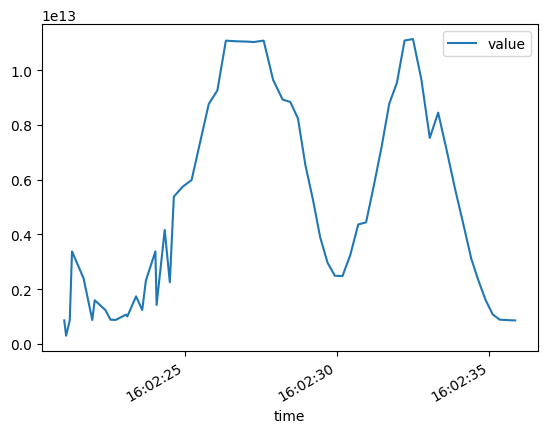

In [98]:
res_df.plot.line(x='time')
